In [1]:
#Import Libraries
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier  
from sklearn.model_selection import train_test_split  
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)  
from imblearn.over_sampling import SMOTE  
import joblib  

plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

In [2]:
# Load the preprocessed splits saved by Notebook 01
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test  shape : {y_test.shape}')
print()
print('Class Distribution in Training Set:')
print(y_train.value_counts().rename({0: 'Not Popular (0)', 1: 'Popular (1)'}))
print()
print('Class Distribution in Test Set:')
print(y_test.value_counts().rename({0: 'Not Popular (0)', 1: 'Popular (1)'}))

X_train shape : (31715, 58)
X_test  shape : (7929, 58)
y_train shape : (31715,)
y_test  shape : (7929,)

Class Distribution in Training Set:
popularity
Popular (1)        16923
Not Popular (0)    14792
Name: count, dtype: int64

Class Distribution in Test Set:
popularity
Popular (1)        4231
Not Popular (0)    3698
Name: count, dtype: int64


### Baseline Random Forest Model

In [3]:
# Train the baseline Random Forest Classifier
# n_estimators=200: 200 decision trees in the ensemble
# max_depth=10: limits tree depth to reduce overfitting
# min_samples_split=5: a node must have at least 5 samples to split
# min_samples_leaf=2: each leaf must have at least 2 samples
# class_weight="balanced": adjusts weights inversely proportional to class frequencies
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all available CPU cores for faster training
)
rf_model.fit(X_train, y_train)  # Train on the training set

# Predictions on the test set
y_pred = rf_model.predict(X_test)          # Predicted class labels
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for class 1

print("Random Forest model trained successfully!")
print(f"Number of Trees : 200")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples    : {X_test.shape[0]}")
print(f"Features Used   : {X_train.shape[1]}")

Random Forest model trained successfully!
Number of Trees : 200
Training Samples: 31715
Test Samples    : 7929
Features Used   : 58


##Model Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC

In [4]:
# Calculate evaluation metrics for the baseline model
# Accuracy  : overall proportion of correct predictions
# Precision : of all predicted positives, how many are truly positive
# Recall    : of all actual positives, how many were correctly identified
# F1-Score  : harmonic mean of precision and recall (useful for imbalanced data)
# ROC-AUC   : area under the ROC curve — measures discriminability
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_prob)

print("===== Random Forest — Model Evaluation =====")
print(f"Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")

===== Random Forest — Model Evaluation =====
Accuracy  : 0.6638  (66.38%)
Precision : 0.6864
Recall    : 0.6809
F1-Score  : 0.6837
ROC-AUC   : 0.7230


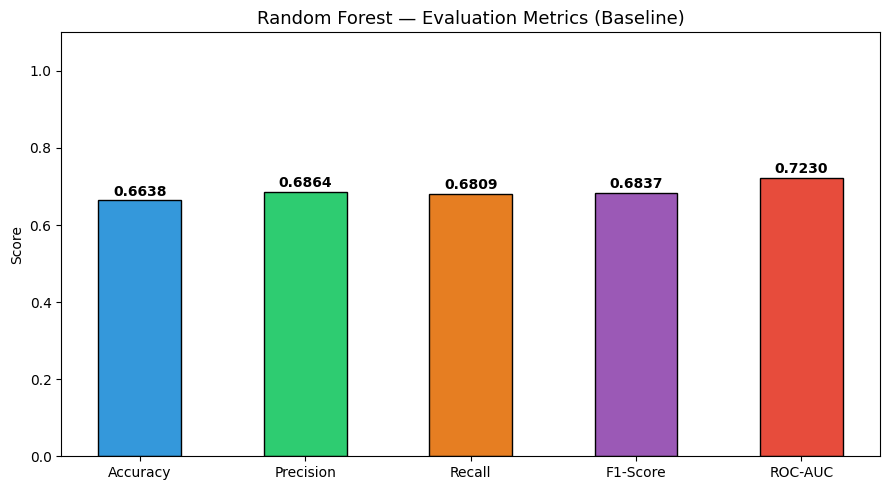

In [5]:
# Bar chart visualization of all evaluation metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
values  = [acc, prec, rec, f1, roc]
colors  = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c"]

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics, values, color=colors, edgecolor="black", width=0.5)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, 1.1)
plt.title("Random Forest — Evaluation Metrics (Baseline)", fontsize=13)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

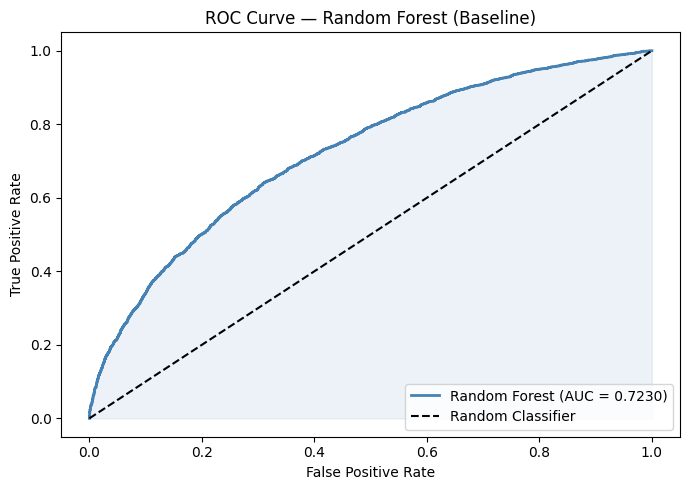

In [6]:
# ROC Curve — plots True Positive Rate vs False Positive Rate at various thresholds
# A random classifier would follow the diagonal; the further the curve is from the
# diagonal, the better the model discriminates between the two classes.
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2,
         label=f"Random Forest (AUC = {roc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1, color="steelblue")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest (Baseline)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

##Classification Report

In [7]:
# Full classification report showing per-class Precision, Recall, F1-Score and Support
print("===== Classification Report — Random Forest (Baseline) =====")
print(classification_report(
    y_test, y_pred,
    target_names=["Not Popular (0)", "Popular (1)"]
))

===== Classification Report — Random Forest (Baseline) =====
                 precision    recall  f1-score   support

Not Popular (0)       0.64      0.64      0.64      3698
    Popular (1)       0.69      0.68      0.68      4231

       accuracy                           0.66      7929
      macro avg       0.66      0.66      0.66      7929
   weighted avg       0.66      0.66      0.66      7929



### Confusion Matrix

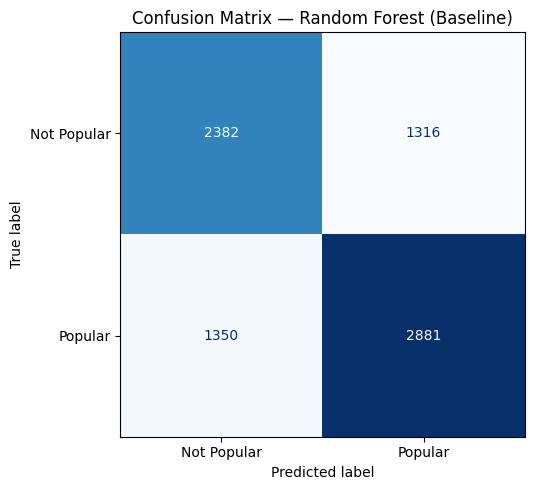

True Negatives  (TN) — Correctly predicted Not Popular : 2382
False Positives (FP) — Incorrectly predicted Popular   : 1316
False Negatives (FN) — Incorrectly predicted Not Popular: 1350
True Positives  (TP) — Correctly predicted Popular     : 2881


In [8]:
# Confusion Matrix — shows True Positives, True Negatives, False Positives, False Negatives
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Popular", "Popular"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Random Forest (Baseline)")
plt.tight_layout()
plt.show()

# Print individual values for clarity
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN) — Correctly predicted Not Popular : {tn}")
print(f"False Positives (FP) — Incorrectly predicted Popular   : {fp}")
print(f"False Negatives (FN) — Incorrectly predicted Not Popular: {fn}")
print(f"True Positives  (TP) — Correctly predicted Popular     : {tp}")

### Effect of Number of Trees (n_estimators)

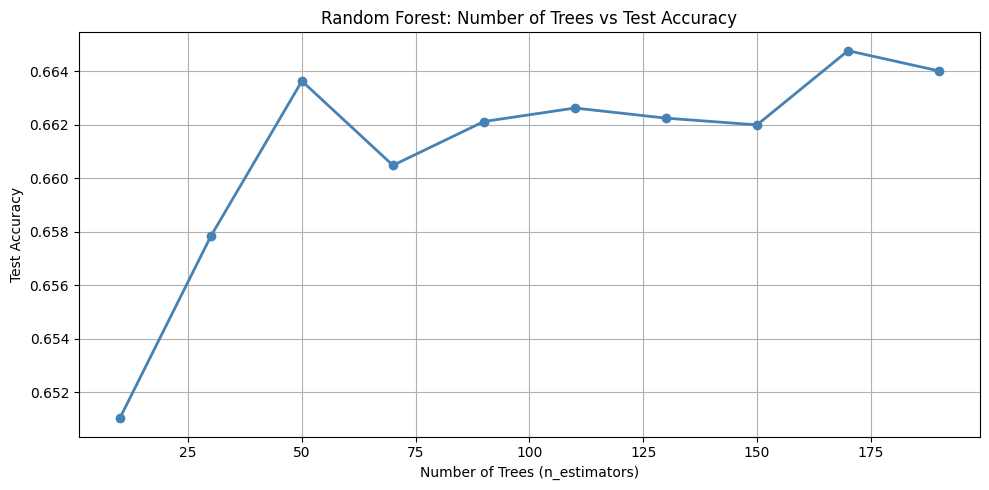


Summary (n_estimators, accuracy):
  k= 10  →  Accuracy: 0.6510
  k= 30  →  Accuracy: 0.6578
  k= 50  →  Accuracy: 0.6636
  k= 70  →  Accuracy: 0.6605
  k= 90  →  Accuracy: 0.6621
  k=110  →  Accuracy: 0.6626
  k=130  →  Accuracy: 0.6623
  k=150  →  Accuracy: 0.6620
  k=170  →  Accuracy: 0.6648
  k=190  →  Accuracy: 0.6640


In [10]:
# Vary n_estimators from 10 to 200 and track accuracy
k_values = list(range(10, 200, 20))  # [10, 30, 50, ..., 190]
results  = []

for k in k_values:
    rf_k = RandomForestClassifier(
        n_estimators=k,
        max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_k.fit(X_train, y_train)
    acc_k = accuracy_score(y_test, rf_k.predict(X_test))
    results.append((k, acc_k))

# Plot k vs Accuracy
ks   = [r[0] for r in results]
accs = [r[1] for r in results]

plt.figure(figsize=(10, 5))
plt.plot(ks, accs, marker="o", color="steelblue", linewidth=2)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Test Accuracy")
plt.title("Random Forest: Number of Trees vs Test Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nSummary (n_estimators, accuracy):")
for k, a in results:
    print(f"  k={k:3d}  →  Accuracy: {a:.4f}")

### SMOTE — Handling Class Imbalance

In [11]:
# Print class distribution BEFORE applying SMOTE
print("===== Original Training Class Distribution =====")
print(f"  Class 0 (Not Popular): {sum(y_train == 0)}")
print(f"  Class 1 (Popular)    : {sum(y_train == 1)}")
print(f"  Total Samples        : {len(y_train)}")

# Apply SMOTE only on training data
# SMOTE creates synthetic minority-class samples by interpolating between existing ones
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Print class distribution AFTER SMOTE
print("===== After SMOTE — Training Class Distribution =====")
print(f"  Class 0 (Not Popular): {sum(y_train_sm == 0)}")
print(f"  Class 1 (Popular)    : {sum(y_train_sm == 1)}")
print(f"  Total Samples        : {len(y_train_sm)}")

===== Original Training Class Distribution =====
  Class 0 (Not Popular): 14792
  Class 1 (Popular)    : 16923
  Total Samples        : 31715
===== After SMOTE — Training Class Distribution =====
  Class 0 (Not Popular): 16923
  Class 1 (Popular)    : 16923
  Total Samples        : 33846


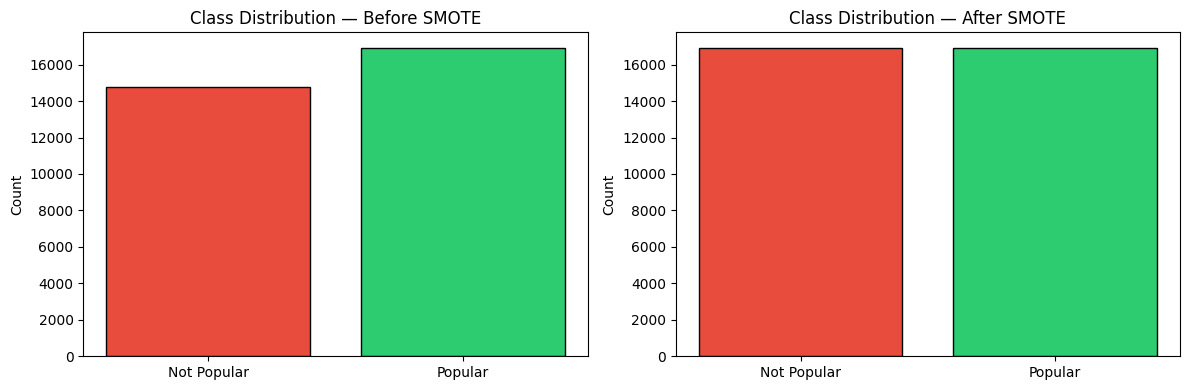

In [12]:
# Visualize class distribution before and after SMOTE side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    ["Not Popular", "Popular"],
    [sum(y_train == 0), sum(y_train == 1)],
    color=["#e74c3c", "#2ecc71"], edgecolor="black"
)
axes[0].set_title("Class Distribution — Before SMOTE")
axes[0].set_ylabel("Count")

axes[1].bar(
    ["Not Popular", "Popular"],
    [sum(y_train_sm == 0), sum(y_train_sm == 1)],
    color=["#e74c3c", "#2ecc71"], edgecolor="black"
)
axes[1].set_title("Class Distribution — After SMOTE")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [14]:
# Train a new Random Forest on the SMOTE-balanced training data
# All other hyperparameters remain the same for a fair comparison
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_smote.fit(X_train_sm, y_train_sm)  # Train on SMOTE-resampled data

# Predict on the ORIGINAL (unchanged) test set
y_pred_sm = rf_smote.predict(X_test)
y_prob_sm = rf_smote.predict_proba(X_test)[:, 1]

print("Random Forest with SMOTE trained successfully!")

Random Forest with SMOTE trained successfully!


### SMOTE Model Evaluation

In [15]:
# Calculate metrics for SMOTE model
acc_sm  = accuracy_score(y_test, y_pred_sm)
prec_sm = precision_score(y_test, y_pred_sm)
rec_sm  = recall_score(y_test, y_pred_sm)
f1_sm   = f1_score(y_test, y_pred_sm)
roc_sm  = roc_auc_score(y_test, y_prob_sm)

print('===== Random Forest with SMOTE — Model Evaluation =====')
print(f'Accuracy  : {acc_sm:.4f}  ({acc_sm*100:.2f}%)')
print(f'Precision : {prec_sm:.4f}')
print(f'Recall    : {rec_sm:.4f}')
print(f'F1-Score  : {f1_sm:.4f}')
print(f'ROC-AUC   : {roc_sm:.4f}')
print()
print('===== Classification Report — Random Forest with SMOTE =====')
print(classification_report(
    y_test, y_pred_sm,
    target_names=['Not Popular (0)', 'Popular (1)']
))

===== Random Forest with SMOTE — Model Evaluation =====
Accuracy  : 0.6631  (66.31%)
Precision : 0.6812
Recall    : 0.6930
F1-Score  : 0.6871
ROC-AUC   : 0.7244

===== Classification Report — Random Forest with SMOTE =====
                 precision    recall  f1-score   support

Not Popular (0)       0.64      0.63      0.64      3698
    Popular (1)       0.68      0.69      0.69      4231

       accuracy                           0.66      7929
      macro avg       0.66      0.66      0.66      7929
   weighted avg       0.66      0.66      0.66      7929



### Before vs After SMOTE Comparison

In [16]:
# Print comparison table
comparison_df = pd.DataFrame({
    'Metric'        : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Without SMOTE' : [acc,    prec,    rec,    f1,    roc],
    'With SMOTE'    : [acc_sm, prec_sm, rec_sm, f1_sm, roc_sm]
}).set_index('Metric').round(4)

print('===== Random Forest — Without SMOTE vs With SMOTE =====')
print(comparison_df.to_string())

===== Random Forest — Without SMOTE vs With SMOTE =====
           Without SMOTE  With SMOTE
Metric                              
Accuracy          0.6638      0.6631
Precision         0.6864      0.6812
Recall            0.6809      0.6930
F1-Score          0.6837      0.6871
ROC-AUC           0.7230      0.7244
